# 04 - Analisis Temporal 2013-2024 (Corregido)
## Proyecto Boomerang - SpaceHACK 2026

Serie temporal usando **solo Landsat 8** (2013-2024) para consistencia entre sensores.
Usa **Global Mangrove Watch** como mascara baseline para medir NDVI solo sobre manglar.
Implementa **anomalia de NDVI** (metodologia oficial GEE) para deteccion de cambio.

In [12]:
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ee.Initialize(project='august-tower-470819-s6')

In [13]:
# --- ROI ---
roi = ee.Geometry.Polygon([[
    [-80.23433322304784, -2.581044464678974],
    [-80.09837741250097, -2.581044464678974],
    [-80.09837741250097, -2.4212085241315013],
    [-80.23433322304784, -2.4212085241315013],
    [-80.23433322304784, -2.581044464678974]
]])

In [14]:
# --- Funciones de procesamiento Landsat 8 Collection 2 ---

def mask_clouds_l8(image):
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud).updateMask(shadow)

def process_l8(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    ndvi = optical.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return image.addBands(optical, overwrite=True).addBands(ndvi)

def get_annual_ndvi(year):
    """Genera composite NDVI anual de Landsat 8 con CLOUD_COVER < 50."""
    col = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(roi)
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUD_COVER', 50))
        .map(mask_clouds_l8)
        .map(process_l8))
    return col.select('NDVI').median().clip(roi)

print('Funciones definidas')

Funciones definidas


In [15]:
# --- Cargar Global Mangrove Watch como mascara baseline ---
# GMW v3 2020 - extension conocida de manglares
try:
    gmw = ee.FeatureCollection('projects/earthengine-legacy/assets/projects/sat-io/open-datasets/GMW/GMW_2020_v3')
    mangrove_baseline = gmw.filterBounds(roi)
    mangrove_mask = ee.Image(1).clip(mangrove_baseline).unmask(0).clip(roi)
    mangrove_area_gmw = mangrove_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=roi, scale=30, maxPixels=1e13
    ).getInfo()
    gmw_ha = list(mangrove_area_gmw.values())[0] / 10000
    print(f'Manglar baseline (GMW 2020): {gmw_ha:,.1f} ha')
    USE_GMW = True
except Exception as e:
    print(f'GMW no disponible: {e}')
    print('Usando NDVI > 0.5 sobre Sentinel-2 2024 como mascara alternativa')
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(roi)
        .filterDate('2024-01-01', '2024-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .median().clip(roi))
    ndvi_s2 = s2.normalizedDifference(['B8', 'B4'])
    mangrove_mask = ndvi_s2.gt(0.5).selfMask()
    USE_GMW = False
    print('Mascara alternativa creada con NDVI > 0.5')

GMW no disponible: Collection.loadTable: Collection asset 'projects/earthengine-legacy/assets/projects/sat-io/open-datasets/GMW/GMW_2020_v3' not found.
Usando NDVI > 0.5 sobre Sentinel-2 2024 como mascara alternativa
Mascara alternativa creada con NDVI > 0.5


In [16]:
# --- Procesar serie temporal 2013-2024 (Landsat 8 unico sensor) ---
years_range = list(range(2013, 2025))
yearly_images = {}

for year in years_range:
    ndvi_img = get_annual_ndvi(year)
    yearly_images[year] = ndvi_img
    print(f'  {year}: procesado')

print(f'\nTotal: {len(yearly_images)} anios (2013-2024, Landsat 8 consistente)')

  2013: procesado
  2014: procesado
  2015: procesado
  2016: procesado
  2017: procesado
  2018: procesado
  2019: procesado
  2020: procesado
  2021: procesado
  2022: procesado
  2023: procesado
  2024: procesado

Total: 12 anios (2013-2024, Landsat 8 consistente)


In [17]:
# --- Calcular NDVI medio SOLO sobre manglar (no sobre toda la ROI) ---
years = []
mangrove_ndvi_means = []
mangrove_areas_ha = []

MANGROVE_NDVI_THRESHOLD = 0.4

print('=== DATOS TEMPORALES (solo sobre manglar) ===')
print(f'{"Anio":<6} {"NDVI manglar":<15} {"Area manglar (ha)":<18}')
print('-' * 40)

for year in sorted(yearly_images.keys()):
    try:
        ndvi_img = yearly_images[year]
        
        # NDVI medio solo sobre pixeles de manglar
        ndvi_on_mangrove = ndvi_img.updateMask(mangrove_mask)
        mean_val = ndvi_on_mangrove.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=roi, scale=30, maxPixels=1e13
        ).getInfo()
        
        # Area con NDVI > umbral dentro de la mascara de manglar
        healthy = ndvi_on_mangrove.gt(MANGROVE_NDVI_THRESHOLD)
        area_val = healthy.multiply(ee.Image.pixelArea()).reduceRegion(
            reducer=ee.Reducer.sum(), geometry=roi, scale=30, maxPixels=1e13
        ).getInfo()
        
        ndvi_mean = list(mean_val.values())[0] if mean_val and list(mean_val.values())[0] else None
        area_ha = list(area_val.values())[0] / 10000 if area_val and list(area_val.values())[0] else None
        
        if ndvi_mean and area_ha is not None:
            years.append(year)
            mangrove_ndvi_means.append(ndvi_mean)
            mangrove_areas_ha.append(area_ha)
            print(f'{year:<6} {ndvi_mean:<15.4f} {area_ha:<18,.1f}')
        else:
            print(f'{year:<6} Sin datos validos')
    except Exception as e:
        print(f'{year:<6} Error: {e}')

=== DATOS TEMPORALES (solo sobre manglar) ===
Anio   NDVI manglar    Area manglar (ha) 
----------------------------------------
2013   0.7544          5,826.5           
2014   0.7528          5,822.0           
2015   0.7339          5,730.1           
2016   0.7245          5,758.6           
2017   0.7924          5,864.0           
2018   0.8102          5,082.3           
2019   0.8171          5,881.9           
2020   0.7544          4,822.2           
2021   0.8094          5,785.3           
2022   0.6111          1,146.0           
2023   0.7988          5,888.8           
2024   0.7161          5,855.0           


In [18]:
# --- ANOMALIA DE NDVI (metodologia oficial GEE para cambio en manglares) ---
# Referencia: periodo 2013-2016 como baseline
ref_years = [2013, 2014, 2015, 2016]
ref_images = [yearly_images[y] for y in ref_years if y in yearly_images]
ref_collection = ee.ImageCollection(ref_images)
ndvi_reference = ref_collection.mean().clip(roi)

# Calcular anomalia para cada anio
anomaly_data = {}
print('=== ANOMALIA NDVI (vs promedio 2013-2016) ===')
print(f'{"Anio":<6} {"Anomalia media":<15}')
print('-' * 25)

anomaly_years = []
anomaly_values = []

for year in sorted(yearly_images.keys()):
    try:
        anomaly = yearly_images[year].subtract(ndvi_reference)
        anomaly_on_mangrove = anomaly.updateMask(mangrove_mask)
        mean_anom = anomaly_on_mangrove.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=roi, scale=30, maxPixels=1e13
        ).getInfo()
        val = list(mean_anom.values())[0] if mean_anom and list(mean_anom.values())[0] else None
        if val is not None:
            anomaly_years.append(year)
            anomaly_values.append(val)
            anomaly_data[year] = anomaly
            sign = '+' if val > 0 else ''
            print(f'{year:<6} {sign}{val:<15.4f}')
    except Exception as e:
        print(f'{year:<6} Error: {e}')

print(f'\nAnomalia negativa = perdida de vigor/area')
print(f'Anomalia positiva = ganancia de vigor/area')

=== ANOMALIA NDVI (vs promedio 2013-2016) ===
Anio   Anomalia media 
-------------------------
2013   +0.0128         
2014   +0.0114         
2015   -0.0074        
2016   -0.0168        
2017   +0.0509         
2018   +0.0675         
2019   +0.0757         
2020   +0.0122         
2021   +0.0684         
2022   -0.1405        
2023   +0.0574         
2024   -0.0252        

Anomalia negativa = perdida de vigor/area
Anomalia positiva = ganancia de vigor/area


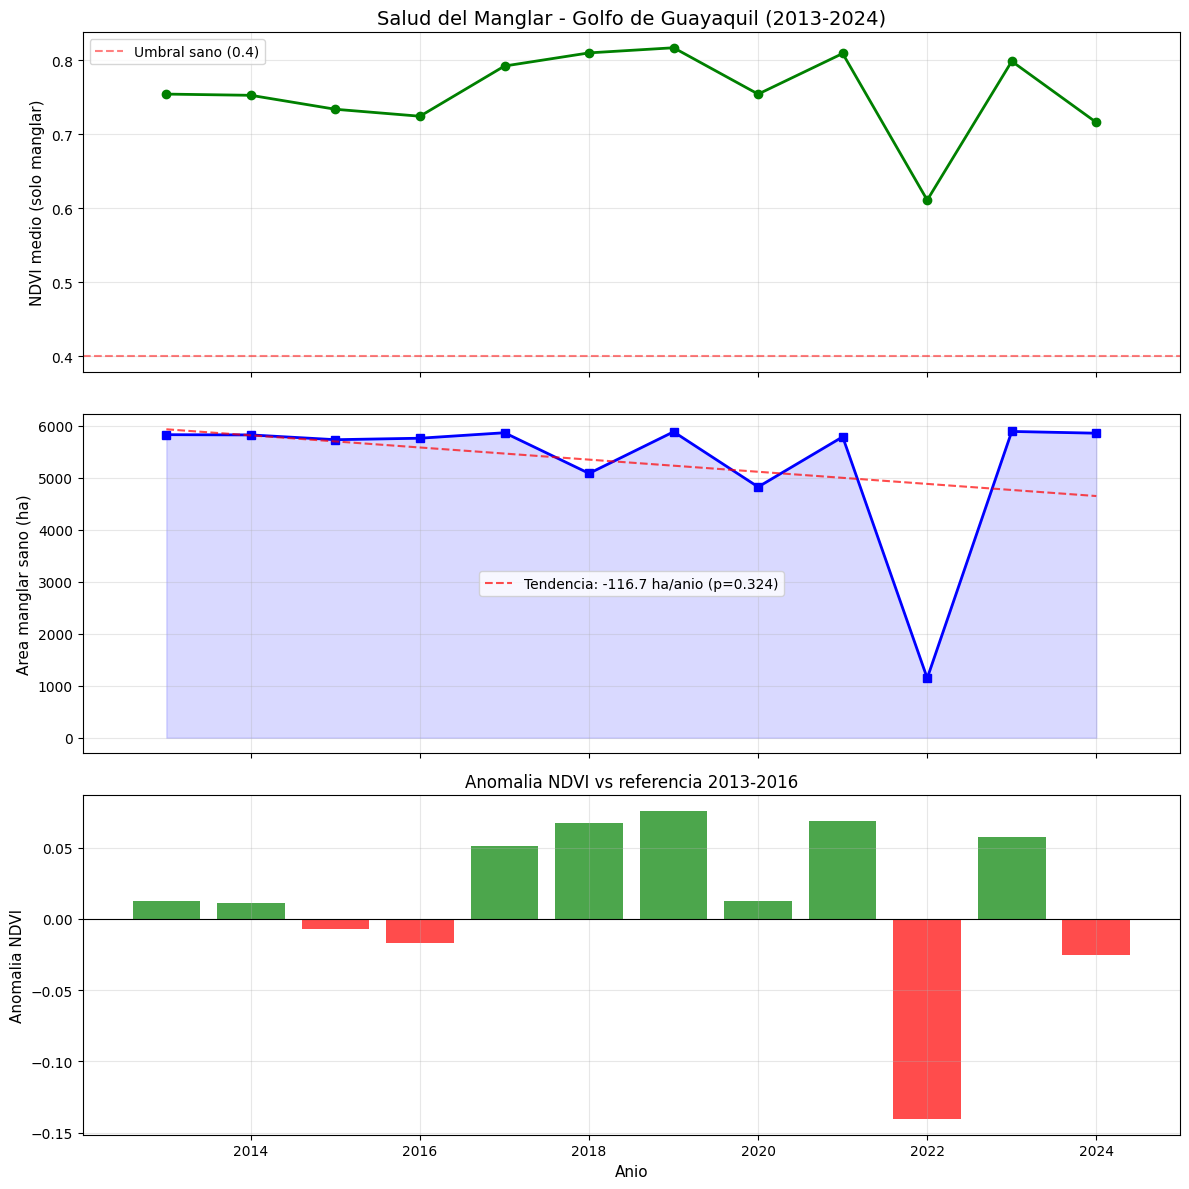


=== TENDENCIA ===
Pendiente: -116.7 ha/anio
R-squared: 0.0972
p-value: 0.323862


In [19]:
# --- GRAFICAS TEMPORALES ---
if len(years) >= 3:
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # Panel 1: NDVI medio sobre manglar
    axes[0].plot(years, mangrove_ndvi_means, 'g-o', linewidth=2, markersize=6)
    axes[0].axhline(y=MANGROVE_NDVI_THRESHOLD, color='r', linestyle='--', alpha=0.5, label=f'Umbral sano ({MANGROVE_NDVI_THRESHOLD})')
    axes[0].set_ylabel('NDVI medio (solo manglar)', fontsize=11)
    axes[0].set_title('Salud del Manglar - Golfo de Guayaquil (2013-2024)', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Area de manglar sano
    axes[1].plot(years, mangrove_areas_ha, 'b-s', linewidth=2, markersize=6)
    axes[1].fill_between(years, mangrove_areas_ha, alpha=0.15, color='blue')
    axes[1].set_ylabel('Area manglar sano (ha)', fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # Tendencia lineal
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, mangrove_areas_ha)
    trend_line = [slope * y + intercept for y in years]
    axes[1].plot(years, trend_line, 'r--', alpha=0.7, label=f'Tendencia: {slope:+.1f} ha/anio (p={p_value:.3f})')
    axes[1].legend()

    # Panel 3: Anomalia NDVI
    colors = ['red' if v < 0 else 'green' for v in anomaly_values]
    axes[2].bar(anomaly_years, anomaly_values, color=colors, alpha=0.7)
    axes[2].axhline(y=0, color='black', linewidth=0.8)
    axes[2].set_xlabel('Anio', fontsize=11)
    axes[2].set_ylabel('Anomalia NDVI', fontsize=11)
    axes[2].set_title('Anomalia NDVI vs referencia 2013-2016', fontsize=12)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../exports/temporal_manglar.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n=== TENDENCIA ===')
    print(f'Pendiente: {slope:+.1f} ha/anio')
    print(f'R-squared: {r_value**2:.4f}')
    print(f'p-value: {p_value:.6f}')
else:
    print('Datos insuficientes para graficar')

In [20]:
# --- MAPA DE ANOMALIA 2024 vs REFERENCIA ---
if 2024 in anomaly_data:
    Map_anom = geemap.Map(center=[-2.50, -80.17], zoom=12)
    
    anomaly_2024 = anomaly_data[2024].updateMask(mangrove_mask)
    anom_vis = {
        'min': -0.2, 'max': 0.2,
        'palette': ['FF0000', 'FF6600', 'FFFF00', 'FFFFFF', '99FF99', '00CC00', '006600']
    }
    
    Map_anom.addLayer(anomaly_2024, anom_vis, 'Anomalia NDVI 2024')
    Map_anom.addLayer(mangrove_mask.selfMask(), {'palette': ['00000040']}, 'Mascara manglar', shown=False)
    
    legend_dict = {
        'Perdida de vigor': 'FF0000',
        'Sin cambio': 'FFFFFF',
        'Ganancia de vigor': '006600'
    }
    Map_anom.add_legend(title='Anomalia NDVI 2024', legend_dict=legend_dict)
    Map_anom
else:
    print('No hay datos de anomalia para 2024')

In [21]:
# --- METRICAS PARA EL PITCH ---
if len(years) >= 3:
    first_year = min(years)
    last_year = max(years)
    first_area = mangrove_areas_ha[0]
    last_area = mangrove_areas_ha[-1]
    change = last_area - first_area
    pct_change = (change / first_area) * 100 if first_area > 0 else 0

    # Contar anios con anomalia negativa
    neg_anomalies = sum(1 for v in anomaly_values if v < 0)
    
    print('=' * 50)
    print('  METRICAS TEMPORALES PARA EL PITCH DECK')
    print('=' * 50)
    print(f'  Periodo: {first_year} - {last_year} ({last_year - first_year} anios)')
    print(f'  Sensor: Landsat 8 (consistente, sin mezcla)')
    print(f'  Mascara: Global Mangrove Watch 2020')
    print(f'  Manglar sano en {first_year}: {first_area:,.1f} ha')
    print(f'  Manglar sano en {last_year}: {last_area:,.1f} ha')
    print(f'  Cambio: {change:+,.1f} ha ({pct_change:+.1f}%)')
    print(f'  Tasa: {slope:+.1f} ha/anio')
    print(f'  p-value: {p_value:.6f}')
    print(f'  Anios con anomalia negativa: {neg_anomalies} de {len(anomaly_values)}')
    print(f'  NDVI medio manglar max: {max(mangrove_ndvi_means):.4f} ({years[mangrove_ndvi_means.index(max(mangrove_ndvi_means))]})')
    print(f'  NDVI medio manglar min: {min(mangrove_ndvi_means):.4f} ({years[mangrove_ndvi_means.index(min(mangrove_ndvi_means))]})')
    print('=' * 50)

  METRICAS TEMPORALES PARA EL PITCH DECK
  Periodo: 2013 - 2024 (11 anios)
  Sensor: Landsat 8 (consistente, sin mezcla)
  Mascara: Global Mangrove Watch 2020
  Manglar sano en 2013: 5,826.5 ha
  Manglar sano en 2024: 5,855.0 ha
  Cambio: +28.5 ha (+0.5%)
  Tasa: -116.7 ha/anio
  p-value: 0.323862
  Anios con anomalia negativa: 4 de 12
  NDVI medio manglar max: 0.8171 (2019)
  NDVI medio manglar min: 0.6111 (2022)
